# SVM Kernel Trick Tutorial Notebook
 
**Tutorial files:** `tutorial.pdf` and `tutorial.html`

This notebook contains the full reproducible demonstration used for the tutorial **"The SVM Kernel Trick: Drawing Curved Boundaries Without Drawing Curved Features"**. It creates the synthetic data set, trains linear/polynomial/RBF SVMs, visualises decision boundaries, and tunes the RBF SVM with cross-validation.

## References used

- Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). *A training algorithm for optimal margin classifiers*. https://doi.org/10.1145/130385.130401
- Cortes, C., & Vapnik, V. (1995). *Support-vector networks*. https://doi.org/10.1007/BF00994018
- scikit-learn `SVC` documentation: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- scikit-learn RBF parameters example: https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html

## 1. Imports and reproducibility settings

The data are synthetic, so there is no external download. I use fixed random seeds so that the examiner can reproduce the same figures and scores.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Make paths work whether the notebook is run from the project root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

DATA_RANDOM_STATE = 2
SPLIT_RANDOM_STATE = 34
CV_RANDOM_STATE = 42
DATA_NOISE = 0.16

# Okabe-Ito colour-blind-safe colours.
BLUE = "#0072B2"
ORANGE = "#D55E00"
LIGHT_BLUE = "#D7EAF7"
LIGHT_ORANGE = "#F7D9C4"
DARK = "#222222"

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 2. Create the two-moons data set

The two-moons data set is useful for teaching because the correct boundary is clearly curved. A straight line can only approximate the separation.

In [2]:
X, y = make_moons(n_samples=360, noise=DATA_NOISE, random_state=DATA_RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SPLIT_RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set:     {X_test.shape[0]} observations")
print("Class counts in full data:", dict(zip(*np.unique(y, return_counts=True))))

Training set: 252 observations
Test set:     108 observations
Class counts in full data: {np.int64(0): np.int64(180), np.int64(1): np.int64(180)}


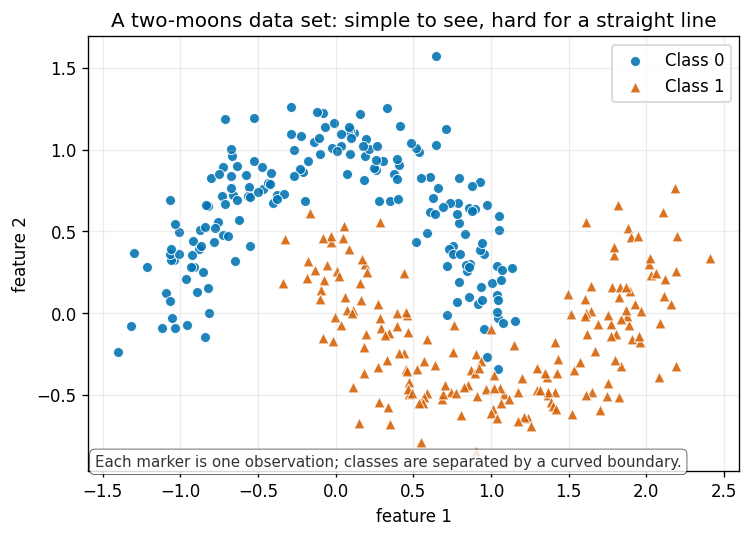

In [3]:
def plot_points(ax, X, y, title=None, legend=True):
    """Plot two-class points using both colour and marker shape."""
    mask0 = y == 0
    mask1 = y == 1
    ax.scatter(
        X[mask0, 0], X[mask0, 1], c=BLUE, marker="o", edgecolor="white",
        linewidth=0.6, s=36, label="Class 0", alpha=0.88
    )
    ax.scatter(
        X[mask1, 0], X[mask1, 1], c=ORANGE, marker="^", edgecolor="white",
        linewidth=0.6, s=42, label="Class 1", alpha=0.88
    )
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    if title:
        ax.set_title(title)
    if legend:
        ax.legend(frameon=True, loc="best")
    ax.grid(True, alpha=0.22)

fig, ax = plt.subplots(figsize=(7, 4.7))
plot_points(ax, X, y, "A two-moons data set: simple to see, hard for a straight line")
ax.text(
    0.01, 0.01,
    "Each marker is one observation; classes are separated by a curved boundary.",
    transform=ax.transAxes, fontsize=9, color="#333333",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, linewidth=0.4),
)
fig.savefig(FIG_DIR / "01_dataset.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

## 3. Helper functions for SVM pipelines and decision boundaries

`StandardScaler` is included in every model. This is important because SVM distances and margins are sensitive to feature scale.

In [4]:
def svm_pipeline(**svc_kwargs) -> Pipeline:
    """Build a scaled SVM pipeline."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(**svc_kwargs)),
    ])


def plot_decision_regions(ax, model, X, y, title):
    """Draw classifier regions, decision boundary and training points."""
    pad = 0.6
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    z = model.predict(grid).reshape(xx.shape)
    ax.contourf(
        xx, yy, z, levels=[-0.5, 0.5, 1.5],
        colors=[LIGHT_BLUE, LIGHT_ORANGE], alpha=0.88,
    )
    decision = model.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, decision, levels=[0], colors=DARK, linewidths=2.0)
    plot_points(ax, X, y, title=title, legend=False)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

## 4. Compare linear, polynomial and RBF kernels

The model and data are the same except for the kernel. This isolates the effect of the kernel on the boundary shape.

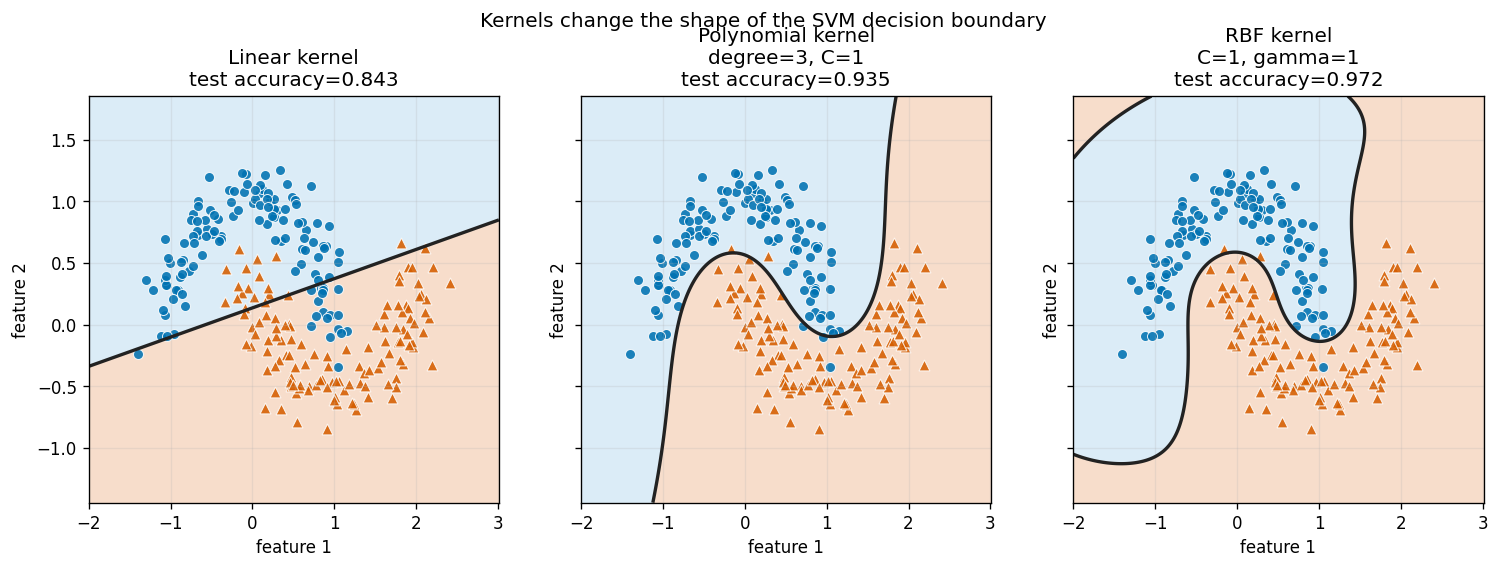

,model,train_accuracy,test_accuracy
0,Linear kernel,0.853175,0.842593
1,"Polynomial kernel degree=3, C=1",0.980159,0.935185
2,"RBF kernel C=1, gamma=1",0.988095,0.972222


In [5]:
models = {
    "Linear kernel": svm_pipeline(kernel="linear", C=1.0),
    "Polynomial kernel\ndegree=3, C=1": svm_pipeline(
        kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0
    ),
    "RBF kernel\nC=1, gamma=1": svm_pipeline(kernel="rbf", C=1.0, gamma=1.0),
}

comparison_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    plot_decision_regions(ax, model, X_train, y_train, f"{name}\ntest accuracy={test_acc:.3f}")
    comparison_rows.append({
        "model": name.replace("\n", " "),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
    })

fig.suptitle("Kernels change the shape of the SVM decision boundary", y=1.04)
fig.savefig(FIG_DIR / "02_kernel_comparison.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(FIG_DIR / "kernel_comparison.csv", index=False)
comparison_df

## 5. Explore RBF hyperparameters C and gamma

- `C` controls how strongly training mistakes are penalised.
- `gamma` controls how local the RBF similarity is.

High `C` and high `gamma` can create very flexible boundaries, but that flexibility can overfit noise.

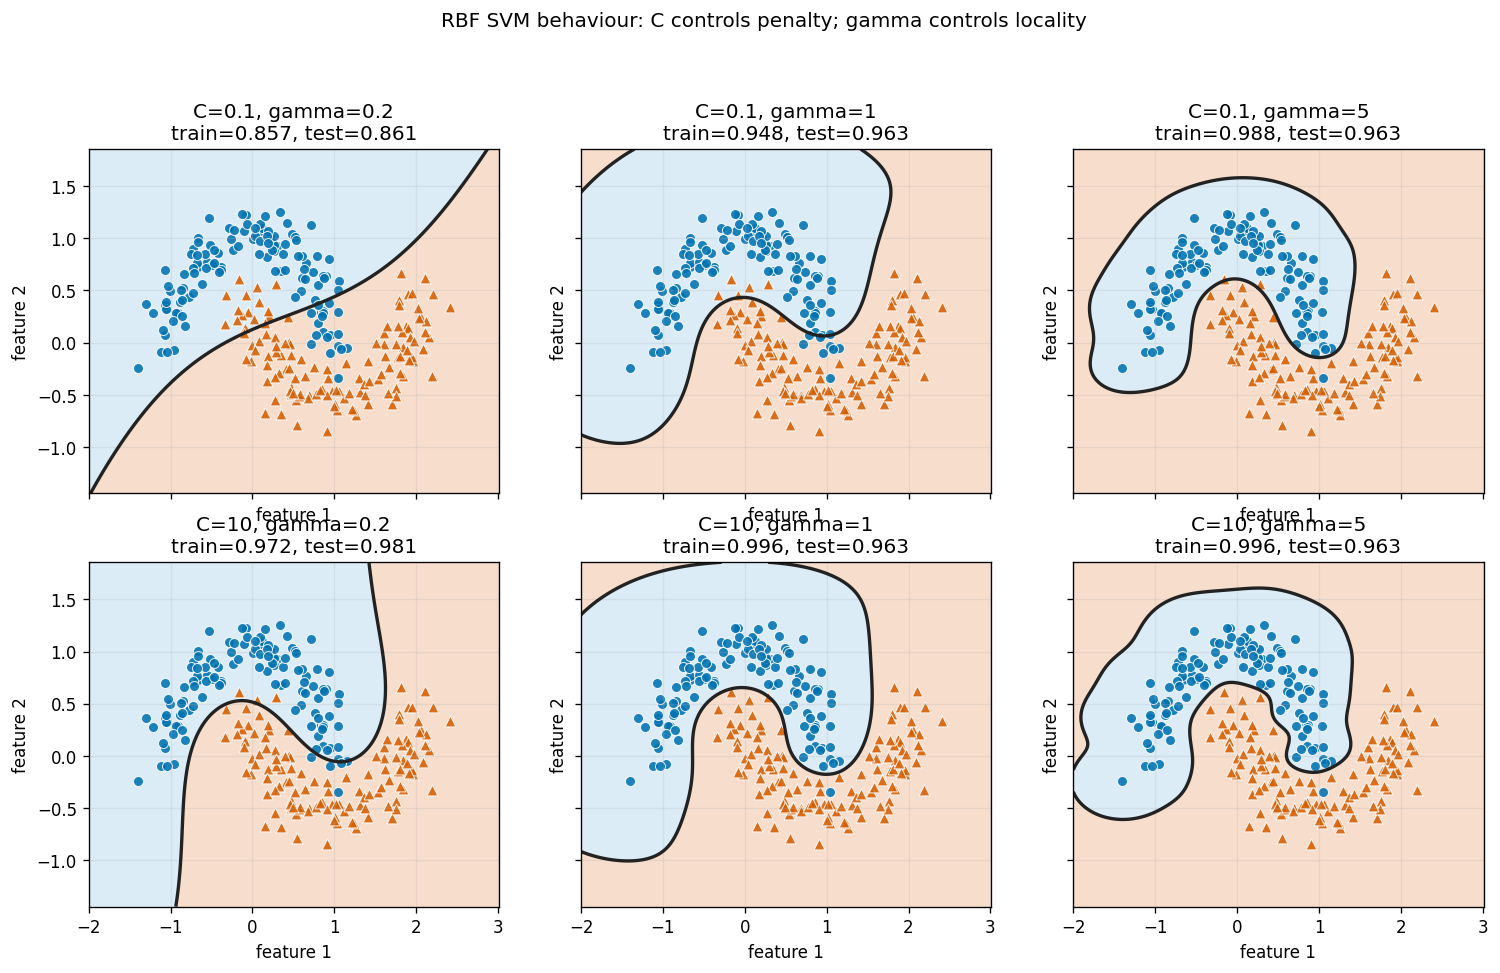

,C,gamma,train_accuracy,test_accuracy
0,0.1,0.2,0.857143,0.861111
1,0.1,1.0,0.948413,0.962963
2,0.1,5.0,0.988095,0.962963
3,10.0,0.2,0.972222,0.981481
4,10.0,1.0,0.996032,0.962963
5,10.0,5.0,0.996032,0.962963


In [6]:
gamma_values = [0.2, 1.0, 5.0]
c_values = [0.1, 10.0]
sensitivity_rows = []

fig, axes = plt.subplots(2, 3, figsize=(15, 8.2), sharex=True, sharey=True)
for row, C in enumerate(c_values):
    for col, gamma in enumerate(gamma_values):
        model = svm_pipeline(kernel="rbf", C=C, gamma=gamma)
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        plot_decision_regions(
            axes[row, col], model, X_train, y_train,
            f"C={C:g}, gamma={gamma:g}\ntrain={train_acc:.3f}, test={test_acc:.3f}",
        )
        sensitivity_rows.append({
            "C": C,
            "gamma": gamma,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
        })

fig.suptitle("RBF SVM behaviour: C controls penalty; gamma controls locality", y=1.02)
fig.savefig(FIG_DIR / "03_rbf_gamma_c.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(FIG_DIR / "rbf_sensitivity.csv", index=False)
sensitivity_df

## 6. Tune the RBF SVM with 5-fold cross-validation

The test set is kept aside. Cross-validation is performed only on the training set, which avoids using test-set information while choosing hyperparameters.

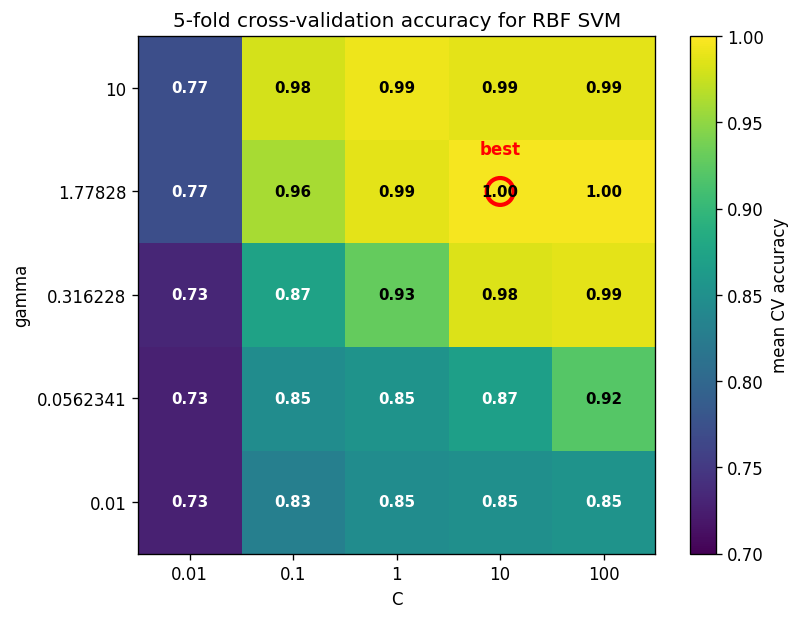

,best_C,best_gamma,best_cv_accuracy,best_test_accuracy
0,10.0,1.778279,0.996,0.972222


In [7]:
param_grid = {
    "svc__C": np.logspace(-2, 2, 5),
    "svc__gamma": np.logspace(-2, 1, 5),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=CV_RANDOM_STATE)

search = GridSearchCV(
    estimator=svm_pipeline(kernel="rbf"),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
)
search.fit(X_train, y_train)

cv_results = pd.DataFrame(search.cv_results_)
heatmap = cv_results.pivot(
    index="param_svc__gamma", columns="param_svc__C", values="mean_test_score"
)
heatmap = heatmap.loc[sorted(heatmap.index.astype(float)), sorted(heatmap.columns.astype(float))]

fig, ax = plt.subplots(figsize=(7.4, 5.6))
im = ax.imshow(heatmap.values, origin="lower", cmap="viridis", vmin=0.70, vmax=1.00)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_yticks(range(len(heatmap.index)))
ax.set_xticklabels([f"{float(v):g}" for v in heatmap.columns])
ax.set_yticklabels([f"{float(v):g}" for v in heatmap.index])
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title("5-fold cross-validation accuracy for RBF SVM")

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        val = heatmap.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val < 0.88 else "black", fontsize=9, fontweight="bold")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("mean CV accuracy")

best = search.best_params_
best_row = np.where(heatmap.index.astype(float) == float(best["svc__gamma"]))[0][0]
best_col = np.where(heatmap.columns.astype(float) == float(best["svc__C"]))[0][0]
ax.scatter(best_col, best_row, s=260, facecolors="none", edgecolors="red", linewidths=2.5)
ax.text(best_col, best_row + 0.32, "best", ha="center", va="bottom", color="red", fontweight="bold")

fig.savefig(FIG_DIR / "04_cv_heatmap.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()

best_model = search.best_estimator_
best_test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
summary = pd.DataFrame([{
    "best_C": float(best["svc__C"]),
    "best_gamma": float(best["svc__gamma"]),
    "best_cv_accuracy": float(search.best_score_),
    "best_test_accuracy": float(best_test_accuracy),
}])
summary.to_csv(FIG_DIR / "results_summary.csv", index=False)
summary

## 7. Final evaluation of the selected model

This is the final held-out test performance for the cross-validation selected RBF SVM. In a real report, this is the number I would use as the final estimate, because the CV score was used during model selection.

In [8]:
y_pred = best_model.predict(X_test)
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

Confusion matrix:
[[53  1]
 [ 2 52]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.96      0.98      0.97        54
     Class 1       0.98      0.96      0.97        54

    accuracy                           0.97       108
   macro avg       0.97      0.97      0.97       108
weighted avg       0.97      0.97      0.97       108



## 8. Conclusion

The kernel trick keeps the SVM's maximum-margin idea but changes the similarity function. On this data, the RBF kernel works well because the class boundary is curved and local. The most important practical habit is to scale features and tune `C` and `gamma` with cross-validation rather than choosing them from the test set.